# 📊 Exploratory Data Analysis (EDA)

### Project: Google Play Store Data Analysis

### Dataset: Google Play Store Dataset

### Author: Muhammad Anas

### Objective

The objective of this project is to explore and understand the Google Play Store dataset using Exploratory Data Analysis (EDA).

### Importing libraries 

In [67]:
#importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [68]:
#loading the dataset 
data=pd.read_csv('D:\DATA_SCIENCE_PROJECTS\DATASETS\googleplaystore.csv')
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### Exploratory Data Analysis

In [69]:
#checking for the shape of the dataset
rows=data.shape[0]
columns=data.shape[1]
print(f'The dataset has {rows} rows and {columns} columns')

The dataset has 10841 rows and 13 columns


In [70]:
#checking the info of the dataset 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [71]:
#checking for the nulls values in the dataset
data.isnull().sum().sort_values(ascending=False)

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
Installs             0
Last Updated         0
Genres               0
dtype: int64

In [72]:
#Finding the percentage of nulls values 
nulls_percentage=(data.isnull().sum()/data.shape[0])*100
nulls_percentage.sort_values(ascending=False)

Rating            13.596532
Current Ver        0.073794
Android Ver        0.027673
Content Rating     0.009224
Type               0.009224
Size               0.000000
Reviews            0.000000
Category           0.000000
App                0.000000
Price              0.000000
Installs           0.000000
Last Updated       0.000000
Genres             0.000000
dtype: float64

In [73]:
#checking Datatypes
data.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

### Data cleaning 


#### Fixing The Nulls Present In The Data

In [74]:
#fixing the nulls in  the Rating columns using mean 
data['Rating'].fillna(data['Rating'].mean(), inplace=True)
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64

In [75]:
#removing the existing nulls values 
data.dropna(inplace=True)
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [76]:
#checking for the duplicated data
data.duplicated().sum()

np.int64(483)

In [77]:
#removing the duplicated data
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [78]:
#checking the duplicated data in the app column
data[data.duplicated(subset=['App'])]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
285,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80804,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
293,OfficeSuite : Free Office + PDF Editor,BUSINESS,4.3,1002859,35M,"100,000,000+",Free,0,Everyone,Business,"August 2, 2018",9.7.14188,4.1 and up
294,Slack,BUSINESS,4.4,51510,Varies with device,"5,000,000+",Free,0,Everyone,Business,"August 2, 2018",Varies with device,Varies with device
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
383,imo free video calls and chat,COMMUNICATION,4.3,4785988,11M,"500,000,000+",Free,0,Everyone,Communication,"June 8, 2018",9.8.000000010501,4.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10647,Motorola FM Radio,VIDEO_PLAYERS,3.9,54815,Varies with device,"100,000,000+",Free,0,Everyone,Video Players & Editors,"May 2, 2018",Varies with device,Varies with device
10715,FarmersOnly Dating,DATING,3.0,1145,1.4M,"100,000+",Free,0,Mature 17+,Dating,"February 25, 2016",2.2,4.0 and up
10720,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0M,"1,000,000+",Free,0,Everyone,Communication,"July 6, 2018",5.2,5.0 and up
10730,FP Notebook,MEDICAL,4.5,410,60M,"50,000+",Free,0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up


In [79]:
#droping the duplicated data in the app column
data.drop_duplicates(subset=['App'], inplace=True)

#### Fixing The DataType Of Features

In [80]:
#fixing the datatype of the Reviews column
data['Reviews'] = data['Reviews'].astype(int)

In [81]:
#fixing the datatypeof the Size column
# Replace 'Varies with device' with NaN
data["Size"] = data["Size"].replace("Varies with device", np.nan)

# Convert KB to MB
data["Size"] = data["Size"].apply(
    lambda x: float(x[:-1]) / 1024 if isinstance(x, str) and x.endswith("k")
    else float(x[:-1]) if isinstance(x, str) and x.endswith("M")
    else x
)

# Convert the column to float
data["Size"] = data["Size"].astype(float)
#filling the nan values with the mean of the size column
data['Size'].fillna(data['Size'].mean(), inplace=True)
data['Size'].head()


0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [82]:
#fixing the datatype of the Installs column by replacing the + with empty string
data['Installs'] = data['Installs'].str.replace('+', '')
data['Installs'] = data['Installs'].str.replace(',', '')
data['Installs'] = data['Installs'].astype(int)
data['Installs'].head()


0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [83]:
#fixing the datatype of the price column by replacing the $ with empty string
data['Price'] = data['Price'].str.replace('$', '')
data["Price"] = data["Price"].astype(float)
data['Price'].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [84]:
#fixing the dataype of the last updated column
data['Last Updated'] = pd.to_datetime(data['Last Updated'])
data['Last Updated'].head() 

0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
Name: Last Updated, dtype: datetime64[ns]

Droping Unnecessary Features 

In [85]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [86]:
#Droping Geners , Current Ver , Android Ver , Type columns 
data.drop(columns=['Genres', 'Current Ver', 'Android Ver', 'Type'], inplace=True)
data.head()

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Last Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,0.0,Everyone,2018-01-07
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,0.0,Everyone,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0.0,Everyone,2018-08-01
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,0.0,Teen,2018-06-08
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,0.0,Everyone,2018-06-20


univariate Analysis

In [ ]:
#Explore the App column
data['App'].describe()

count          9648
unique         9648
top       Cardio-FR
freq              1
Name: App, dtype: object

In [88]:
#explore the Category column
data['Category'].describe()

count       9648
unique        33
top       FAMILY
freq        1828
Name: Category, dtype: object

In [89]:
#explore the Rating colum
data['Rating'].describe()

count    9648.000000
mean        4.176346
std         0.494527
min         1.000000
25%         4.000000
50%         4.200000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

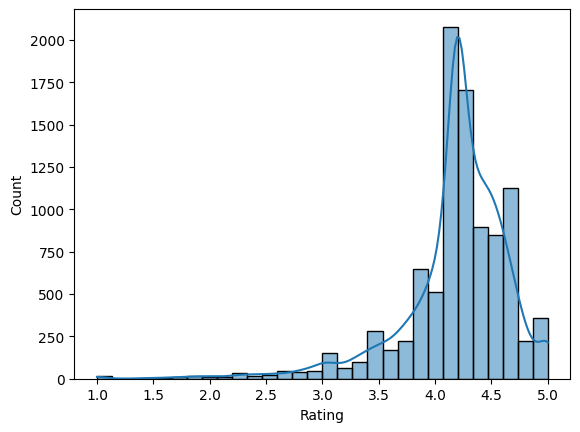

In [90]:
#creating a histogram of the Rating column
sns.histplot(data['Rating'],bins=30,kde=True)
plt.show()



In [91]:
#explore the Reviews column
data['Reviews'].describe()

count    9.648000e+03
mean     2.168369e+05
std      1.832349e+06
min      0.000000e+00
25%      2.500000e+01
50%      9.690000e+02
75%      2.944925e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [92]:
#explore the Size column
data['Size'].describe()

count    9648.000000
mean       20.413556
std        20.398995
min         0.008301
25%         5.300000
50%        16.000000
75%        25.000000
max       100.000000
Name: Size, dtype: float64

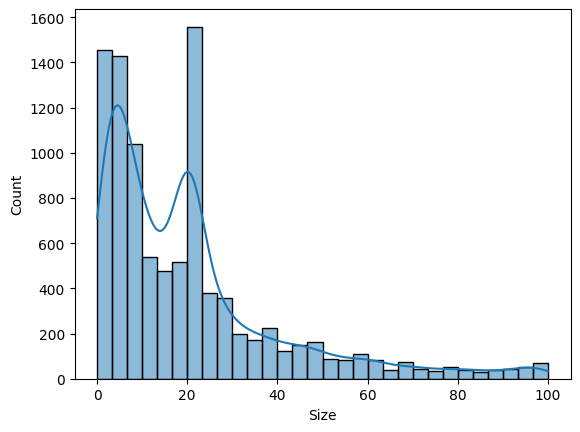

In [93]:
#creating a histogram of the Size column
sns.histplot(data['Size'],bins=30,kde=True)
plt.show()

In [94]:
#let's explore the Installs column
data['Installs'].describe()

count    9.648000e+03
mean     7.786211e+06
std      5.378830e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [95]:
#lets explore the Price column
data['Price'].describe()

count    9648.000000
mean        1.100193
std        16.861727
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

In [96]:
#lets explore the Content Rating column
data['Content Rating'].describe()

count         9648
unique           6
top       Everyone
freq          7893
Name: Content Rating, dtype: object

Bivariate Analysis

In [ ]:
#checking the average rating by category
category_rating = data.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print(category_rating)

Category
ART_AND_DESIGN         4.367937
EVENTS                 4.363647
EDUCATION              4.362969
BOOKS_AND_REFERENCE    4.309292
PERSONALIZATION        4.302621
PARENTING              4.282223
BEAUTY                 4.260882
GAME                   4.244720
SOCIAL                 4.239164
WEATHER                4.238650
HEALTH_AND_FITNESS     4.235441
SHOPPING               4.226007
SPORTS                 4.211591
AUTO_AND_VEHICLES      4.190824
PRODUCTIVITY           4.185331
LIBRARIES_AND_DEMO     4.182732
COMICS                 4.181905
FAMILY                 4.181416
FOOD_AND_DRINK         4.175715
MEDICAL                4.173672
PHOTOGRAPHY            4.159716
HOUSE_AND_HOME         4.157028
NEWS_AND_MAGAZINES     4.135697
ENTERTAINMENT          4.135294
COMMUNICATION          4.134943
BUSINESS               4.133938
FINANCE                4.125257
LIFESTYLE              4.111781
TRAVEL_AND_LOCAL       4.087611
TOOLS                  4.059492
VIDEO_PLAYERS          4.058283

In [ ]:
#Checking the average size by category
category_rating = data.groupby("Category")["Size"].mean().sort_values(ascending=False)
print(category_rating)

Category
GAME                   39.942734
FAMILY                 26.831541
SPORTS                 23.609587
TRAVEL_AND_LOCAL       23.408130
PARENTING              22.303022
ENTERTAINMENT          22.063874
HEALTH_AND_FITNESS     20.619568
FOOD_AND_DRINK         20.477012
AUTO_AND_VEHICLES      20.081131
EDUCATION              19.398851
MEDICAL                19.272477
FINANCE                17.773955
MAPS_AND_NAVIGATION    17.108985
SOCIAL                 16.910581
VIDEO_PLAYERS          16.813189
HOUSE_AND_HOME         16.690585
PHOTOGRAPHY            16.662860
SHOPPING               16.319544
DATING                 15.994621
LIFESTYLE              15.372745
WEATHER                14.931394
EVENTS                 14.669079
COMICS                 14.621843
BUSINESS               14.552732
BEAUTY                 14.544931
PRODUCTIVITY           14.133244
NEWS_AND_MAGAZINES     14.127635
BOOKS_AND_REFERENCE    14.112869
COMMUNICATION          13.416875
ART_AND_DESIGN         12.779795
P

In [ ]:
#checking the average price by category
category_rating = data.groupby("Category")["Price"].mean().sort_values(ascending=False)
print(category_rating)

Category
FINANCE                8.408203
LIFESTYLE              6.398022
MEDICAL                2.520759
EVENTS                 1.718594
FAMILY                 1.312292
PRODUCTIVITY           0.670936
BOOKS_AND_REFERENCE    0.541946
PHOTOGRAPHY            0.420925
BUSINESS               0.417357
WEATHER                0.410380
PERSONALIZATION        0.398369
TOOLS                  0.322739
SPORTS                 0.307692
GAME                   0.296465
COMMUNICATION          0.263937
TRAVEL_AND_LOCAL       0.228082
HEALTH_AND_FITNESS     0.223438
MAPS_AND_NAVIGATION    0.205725
DATING                 0.160468
PARENTING              0.159667
AUTO_AND_VEHICLES      0.158471
EDUCATION              0.150924
ART_AND_DESIGN         0.094762
ENTERTAINMENT          0.078235
FOOD_AND_DRINK         0.075714
SOCIAL                 0.066820
VIDEO_PLAYERS          0.064172
SHOPPING               0.027129
NEWS_AND_MAGAZINES     0.015669
LIBRARIES_AND_DEMO     0.011928
HOUSE_AND_HOME         0.000000

In [ ]:
#Top 10 Most Installs Apps
top_10_apps = data.nlargest(10, "Installs")

print(top_10_apps[["App", "Installs"]])

                                           App    Installs
152                          Google Play Books  1000000000
335   Messenger – Text and Video Chat for Free  1000000000
336                         WhatsApp Messenger  1000000000
338               Google Chrome: Fast & Secure  1000000000
340                                      Gmail  1000000000
341                                   Hangouts  1000000000
391              Skype - free IM & video calls  1000000000
865                          Google Play Games  1000000000
1654                            Subway Surfers  1000000000
2544                                  Facebook  1000000000


In [ ]:
#finding the highest price app 
highest_price_app = data.loc[data["Price"].idxmax()]

print(highest_price_app[["App", "Price", "Category"]])

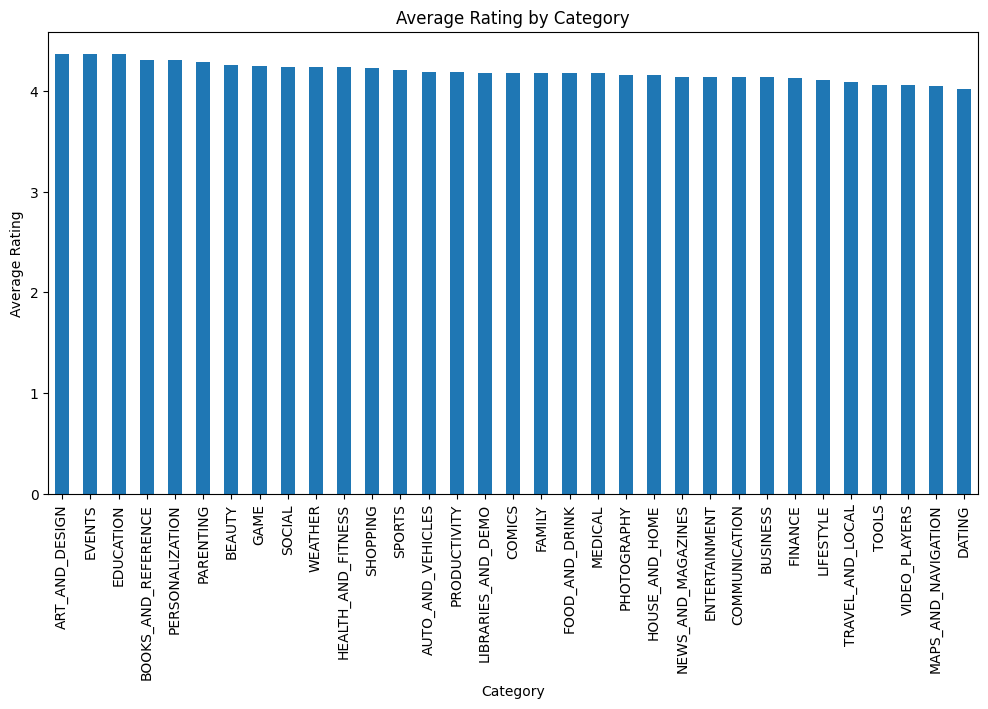

In [ ]:
#ploting the average rating by category
category_rating = data.groupby("Category")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
category_rating.plot(kind="bar")

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=90)

plt.show()

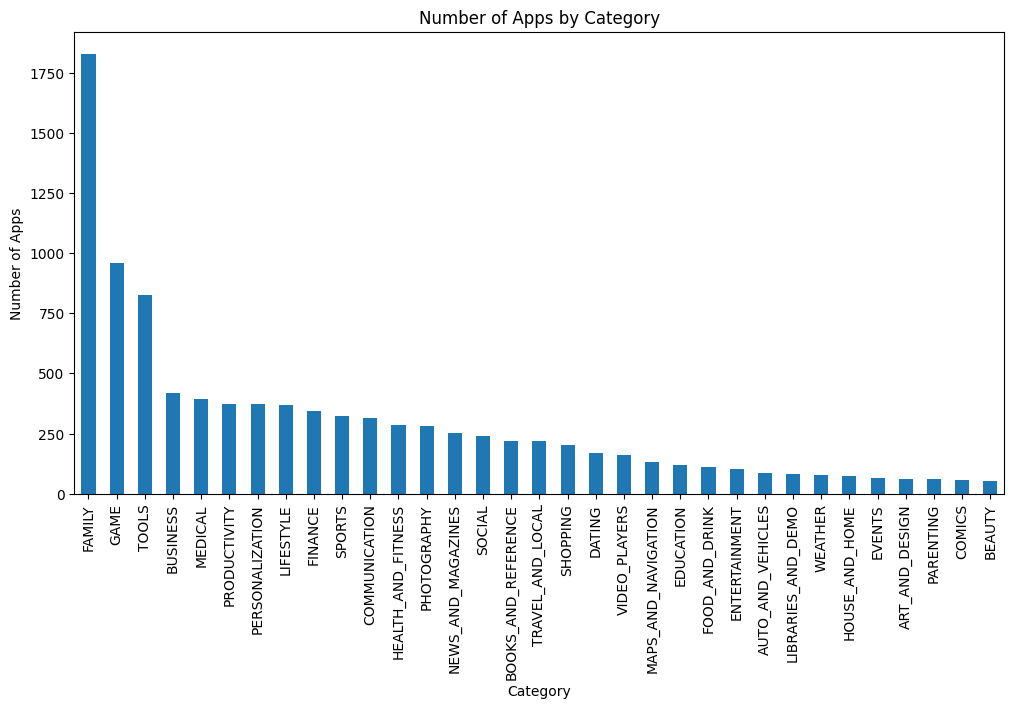

In [ ]:
#ploting the number of apps by category
category_count = data["Category"].value_counts()

plt.figure(figsize=(12,6))
category_count.plot(kind="bar")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=90)

plt.show()

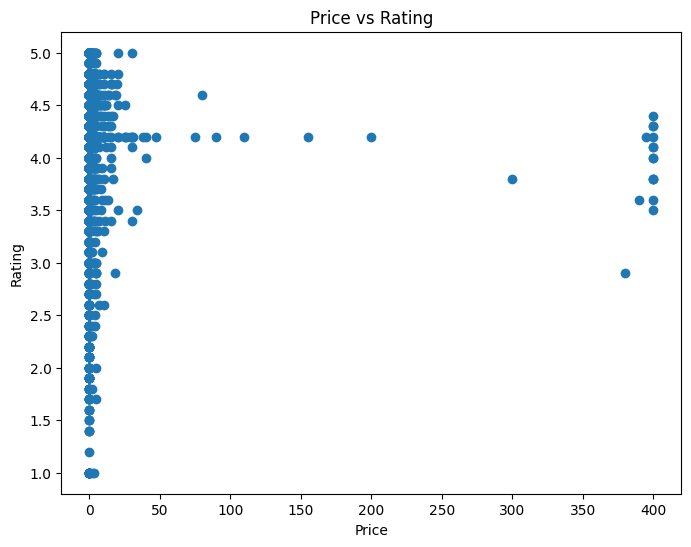

In [ ]:
#ploting Price vs Rating
plt.figure(figsize=(8,6))

plt.scatter(data["Price"], data["Rating"])

plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()

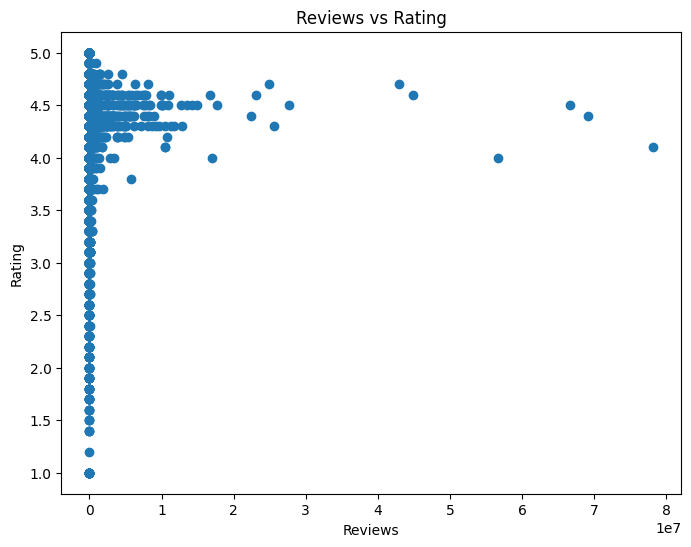

In [ ]:
#ploting Reviews vs Rating
plt.figure(figsize=(8,6))

plt.scatter(data["Reviews"], data["Rating"])

plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")

plt.show()

In [ ]:
#checking the data 
data.head()

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Last Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,0.0,Everyone,2018-01-07
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,0.0,Everyone,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0.0,Everyone,2018-08-01
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,0.0,Teen,2018-06-08
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,0.0,Everyone,2018-06-20


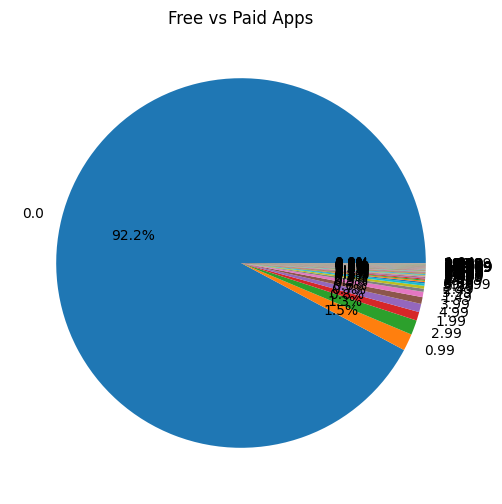

In [ ]:
#Free vs Paid apps
type_count = data["Price"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(type_count,
        labels=type_count.index,
        autopct="%1.1f%%")

plt.title("Free vs Paid Apps")

plt.show()

Multivarate Analysis

In [122]:
#finding the highest price app 
highest_price_app = data.loc[data["Price"].idxmax()]

print(highest_price_app[["App", "Price", "Category"]])

App         I'm Rich - Trump Edition
Price                          400.0
Category                   LIFESTYLE
Name: 4367, dtype: object


In [ ]:
#hghest Rating apps
highest_rating = data["Rating"].max()
highest_rated_apps = data[data["Rating"] == highest_rating]

print(highest_rated_apps[["App", "Rating", "Price", "Category"]])

                                              App  Rating  Price   Category
329                  Hojiboy Tojiboyev Life Hacks     5.0    0.0     COMICS
612                 American Girls Mobile Numbers     5.0    0.0     DATING
615                                  Awake Dating     5.0    0.0     DATING
633                         Spine- The dating app     5.0    0.0     DATING
636    Girls Live Talk - Free Text and Video Chat     5.0    0.0     DATING
...                                           ...     ...    ...        ...
10721                           Mad Dash Fo' Cash     5.0    0.0       GAME
10742                       GKPB FP Online Church     5.0    0.0  LIFESTYLE
10776                            Monster Ride Pro     5.0    0.0       GAME
10820                             Fr. Daoud Lamei     5.0    0.0     FAMILY
10837            Fr. Mike Schmitz Audio Teachings     5.0    0.0     FAMILY

[271 rows x 4 columns]


In [ ]:
#lowest Rating app
lowest_rating_app = data.loc[data["Rating"].idxmin()]

print(lowest_rating_app[["App", "Rating", "Price", "Installs", "Category"]])

App         House party - live chat
Rating                          1.0
Price                           0.0
Installs                         10
Category                     DATING
Name: 625, dtype: object


In [ ]:
#Highest Rating app
highest_rating_app = data.loc[data["Rating"].idxmax()]

print(highest_rating_app[["App", "Rating", "Price", "Category"]])

App         Hojiboy Tojiboyev Life Hacks
Rating                               5.0
Price                                0.0
Category                          COMICS
Name: 329, dtype: object


In [ ]:
#checking the Higest Average Rated Category 
data.groupby("Category")[["Rating", "Price"]].mean().sort_values("Rating", ascending=False)

,Rating,Price
Category,,
ART_AND_DESIGN,4.367937,0.094762
EVENTS,4.363647,1.718594
EDUCATION,4.362969,0.150924
BOOKS_AND_REFERENCE,4.309292,0.541946
PERSONALIZATION,4.302621,0.398369
PARENTING,4.282223,0.159667
BEAUTY,4.260882,0.000000
GAME,4.244720,0.296465
SOCIAL,4.239164,0.066820


In [ ]:
#check the Average Rating , Reviews, Installs and Price by Category
data.groupby("Category")[["Rating", "Reviews", "Installs", "Price"]].mean()

,Rating,Reviews,Installs,Price
Category,,,,
ART_AND_DESIGN,4.367937,22526.158730,1.814811e+06,0.094762
AUTO_AND_VEHICLES,4.190824,13690.188235,6.250613e+05,0.158471
BEAUTY,4.260882,7476.226415,5.131519e+05,0.000000
BOOKS_AND_REFERENCE,4.309292,75662.018100,7.538319e+06,0.541946
BUSINESS,4.133938,23548.202381,1.659916e+06,0.417357
COMICS,4.181905,41822.696429,8.032348e+05,0.000000
COMMUNICATION,4.134943,907337.676190,3.504215e+07,0.263937
DATING,4.018442,21190.315789,8.241293e+05,0.160468
EDUCATION,4.362969,112303.764706,2.965983e+06,0.150924


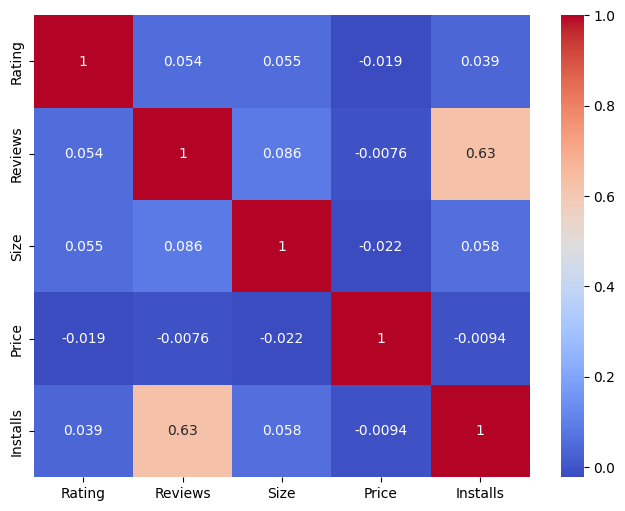

In [ ]:
#Checking the Corelation Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    data[["Rating", "Reviews", "Size", "Price", "Installs"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# 📌 Observations

### 1. Dataset Overview
- The original dataset contains **10,841 rows** and **13 features (columns)**.
- Each row represents a single application, while each column contains information such as the app name, category, rating, installs, reviews, size, and price.

---

### 2. Missing Values
- The **Rating** column contains the highest number of missing values, with **1,474 missing entries**.
- These missing values were handled during the data preprocessing stage to improve the quality and reliability of the dataset.

---

### 3. Data Preprocessing
- After performing basic data preprocessing, such as handling missing values, removing unnecessary columns, and correcting data types, the dataset was reduced to **9,648 rows** and **9 columns**.
- The cleaned dataset is now suitable for exploratory data analysis (EDA) and machine learning tasks.

---

### 4. App Categories
- The dataset contains **13 unique app categories**.
- The **Family** category has the highest number of applications, with **1,828 apps**, making it the most represented category in the dataset.

---

### 5. Average App Rating
- The average rating of all applications in the dataset is **4.176**.
- This indicates that most apps on the Google Play Store receive generally positive user ratings.

---

### 6. Average App Size
- The average application size is approximately **20.14 MB**.
- This suggests that most applications in the dataset are relatively lightweight and do not require a large amount of storage space.

---

### 7. Content Rating
- The **Everyone** content rating is the most common, with **7,893 applications**.
- This indicates that the majority of apps on the Google Play Store are designed to be suitable for users of all age groups.

---

### 8. Most Installed App
- **Google Play Books** has the highest number of installs in the dataset.
- This highlights its popularity and widespread adoption among Android users.

---
### 9. Free vs Paid Apps
- Approximately **92.2%** of the applications in the dataset are **free**, while only **7.8%** are paid.
- This indicates that the Google Play Store is dominated by free applications, as developers often use the free app model to reach a larger audience.

---

### 10. Lowest Rated App
- **House Party Live Chat** is the **lowest-rated application** in the dataset with a rating of **1.0**.
- The app belongs to the **Dating** category and has only **10 installs**, indicating a very limited user base and poor user satisfaction.

---

### 11. Highest Rated App
- **Hajiboyer Tojiboyer Life Hack** is the **highest-rated application** in the dataset.
- This indicates that the app has received excellent feedback from its users.

> **Note:** If the app has very few reviews, mention that as well because a perfect rating based on a small number of reviews may not represent overall user satisfaction.

---

### 12. Highest Average Rated Category
- The **Art & Design** category has the **highest average app rating** among all categories.
- The category also has an average of approximately **1,814,811 installs**, indicating that these apps are both highly rated and widely downloaded.

---

### 13. Lowest Average Rated Category
- The **Weather** category has the **lowest average rating**, with an average rating of approximately **4.23**.
- Although it has the lowest average rating among all categories, the overall rating is still relatively high, indicating generally positive user feedback.

---

### 14. Most Expensive App
- **I'm Rich - Trump Edition** is the **most expensive application** in the dataset, priced at **$400**.
- The app belongs to the **Lifestyle** category, making it one of the premium-priced applications available on the Google Play Store.

---

### 15. Correlation Analysis
- The correlation matrix shows a **moderate positive correlation** between **Reviews** and **Installs**.
- This indicates that applications with more installs generally receive more user reviews.
- No other numerical features exhibit a strong or moderate correlation, suggesting that most variables are only weakly related to one another.